<div align="center" >
    <br /><br />
    <h1>Universidad de Sevilla</h1>
    <h2>Escuela Técnica Superior de Ingeniería Informática</h2>
    <h3>Grado en Ingeniería del Software</h3>
    <img src="images/logo_us.png" alt="Logo Universidad de Sevilla" width="250" />
    <br />
    <hr />
    <br />
    <h1>Construcción de modelos base de clasificación</h1>
    <h2>Validación y evaluación sobre características manuales</h2>
    <br />
    <hr />
    <br />
    <p><strong>Asignatura:</strong> Inteligencia Artificial</p>
    <p><strong>Grupo:</strong> Aprendizaje Automático Relacional - G5</p>
    <p><strong>Curso Académico:</strong> 2025/2026</p>
</div>

<br /><br /><br /><br />

<div align="right" >
    <p><strong>Autores:</strong><br />
    Juan Antonio Fernández Ruiz<br />
    Eulogio Reyes Díaz<br />
</div>

<div align="right" >
    <p><strong>Fecha:</strong> 7 de Junio de 2026</p>
</div>

<br /><br />

# Construcción de modelos base

## 0. Introducción y objetivo

- 1.  **La partición de los datos:** Vamos a dividir el conjunto de ejemplos en subconjuntos de entrenamiento y prueba. Para ello, aplicaremos la técnica de validación por retención (*holdout validation*).
- 2.  **La inicialización de los algoritmos:** El trabajo exige construir al menos tres modelos de clasificación estándar. Importaremos y configuraremos los métodos propuestos en la teoría, tales como **k-vecinos más cercanos (kNN)**, **árboles de clasificación**, modelos probabilísticos como **Naive Bayes**, o **redes neuronales** multicapa.
- 3.  **La configuración de la búsqueda de hiper-parámetros:** Vamos a dejar preparada la estructura de código para realizar una **búsqueda en rejilla** (*grid search*) que evalúe diferentes combinaciones de hiper-parámetros para cada modelo.
- 4.  **Las métricas de rendimiento:** Programar el código para extraer la matriz de confusión y calcular medidas como la tasa de acierto (*accuracy*) o la tasa de error, necesarias para estimar la capacidad de generalización.

## Indice de contenidos

- [0. Introduccion y objetivo](#0-introduccion-y-objetivo)
- [1. Enfoque de implementacion](#1-enfoque-de-implementacion)
- [2. Configuracion y carga de datos](#2-configuración-y-carga-de-datos)
- [3. Preparacion de entrenamiento y prueba](#3-preparación-de-entrenamiento-y-prueba)
- [4. Modelos base y espacios de busqueda](#4-modelos-base-y-espacios-de-búsqueda)
- [5. Validacion cruzada y ajuste de hiperparametros](#5-validación-cruzada-y-ajuste-de-hiperparámetros)
- [6. Evaluacion final en el conjunto de prueba](#6-evaluación-final-en-el-conjunto-de-prueba)
- [7. Seleccion del mejor modelo y analisis detallado](#7-selección-del-mejor-modelo-y-análisis-detallado)
- [8. Persistencia de artefactos (trazabilidad)](#8-persistencia-de-artefactos-trazabilidad)
- [9. Conclusiones y siguientes pasos](#9-conclusiones-y-siguientes-pasos)

## 1. Enfoque de implementacion

En esta sección vamos a construir modelos base de clasificación para Cora usando Scikit-learn, siguiendo una metodología reproducible:

1. Preparar los datos de entrada y salida.
2. Separar entrenamiento y prueba con estratificación.
3. Ajustar hiperparámetros con validación cruzada.
4. Evaluar en test con métricas globales y por clase.

In [1]:
import warnings
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 120)

## 2. Configuración y carga de datos

Primero buscamos un CSV consolidado (opción A). Si no existe, construimos el dataset combinado a partir de:

- Atributos nativos de cora.content.
- Estructura relacional en cora.cites.

Este enfoque permite ejecutar el notebook de forma autónoma sin depender de pasos manuales previos.

In [2]:
def cargar_datos_cora(base_dir: Path):
    csv_candidates = [
        base_dir / "data" / "cora_features_completas.csv",
        base_dir / "data" / "cora" / "cora_features_completas.csv",
        base_dir / "notebooks" / "cora_features_completas.csv",
    ]

    for csv_path in csv_candidates:
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            if "paper_id" in df.columns:
                df = df.set_index("paper_id")

            posibles_label = ["class_label", "label", "target", "y"]
            label_col = next((col for col in posibles_label if col in df.columns), None)
            if label_col is None:
                raise ValueError(
                    f"Se encontró {csv_path}, pero no contiene ninguna columna de etiqueta esperada: {posibles_label}"
                )

            y = df[label_col].copy()
            X = df.drop(columns=[label_col])
            return X, y, f"CSV consolidado: {csv_path}"

    content_path = base_dir / "data" / "cora" / "cora.content"
    cites_path = base_dir / "data" / "cora" / "cora.cites"

    if not content_path.exists() or not cites_path.exists():
        raise FileNotFoundError("No se encontró ni CSV consolidado ni archivos base de Cora.")

    df_content = pd.read_csv(content_path, sep="\t", header=None)
    paper_ids = df_content.iloc[:, 0].astype(int)
    y = df_content.iloc[:, -1].astype(str)

    feature_cols = [f"word_{i}" for i in range(df_content.shape[1] - 2)]
    X_nativo = pd.DataFrame(df_content.iloc[:, 1:-1].values, index=paper_ids, columns=feature_cols)
    X_nativo.index.name = "paper_id"
    y.index = X_nativo.index
    y.name = "class_label"

    df_cites = pd.read_csv(cites_path, sep="\t", header=None, names=["source", "target"])
    df_cites = df_cites.astype(int)

    G = nx.from_pandas_edgelist(df_cites, source="source", target="target", create_using=nx.Graph())
    G.add_nodes_from(X_nativo.index.tolist())

    degree = nx.degree_centrality(G)
    betweenness = nx.betweenness_centrality(G)
    clustering = nx.clustering(G)

    comunidades = nx.community.louvain_communities(G, seed=RANDOM_STATE)
    map_comunidad = {}
    for id_comunidad, nodos in enumerate(comunidades):
        for nodo in nodos:
            map_comunidad[nodo] = id_comunidad

    X_rel = pd.DataFrame(
        {
            "centralidad_grado": pd.Series(degree),
            "centralidad_betweenness": pd.Series(betweenness),
            "coeficiente_clustering": pd.Series(clustering),
            "comunidad_louvain": pd.Series(map_comunidad),
        }
    )
    X_rel.index.name = "paper_id"

    X = X_nativo.join(X_rel, how="left").fillna(0)
    return X, y, "Reconstruido desde cora.content + cora.cites"


base_dir = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
X, y, fuente_datos = cargar_datos_cora(base_dir)

print(f"Fuente de datos: {fuente_datos}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Distribución de clases (top 7):")
print(y.value_counts().head(7))

Fuente de datos: CSV consolidado: C:\Users\juana\aprendizaje-automatico-relacional\data\cora_features_completas.csv
X shape: (2708, 1437)
y shape: (2708,)
Distribución de clases (top 7):
class_label
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180
Name: count, dtype: int64


## 3. Preparación de entrenamiento y prueba

Dividimos el dataset en train/test con estratificación para conservar la proporción de clases en ambos subconjuntos. Esto evita sesgos al evaluar modelos multiclase con clases desbalanceadas.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print("\nDistribución de clases en train (top 7):")
print(y_train.value_counts(normalize=True).head(7))
print("\nDistribución de clases en test (top 7):")
print(y_test.value_counts(normalize=True).head(7))

Train shape: (2166, 1437)
Test shape:  (542, 1437)

Distribución de clases en train (top 7):
class_label
Neural_Networks           0.301939
Probabilistic_Methods     0.157433
Genetic_Algorithms        0.154201
Theory                    0.129732
Case_Based                0.109880
Reinforcement_Learning    0.080332
Rule_Learning             0.066482
Name: proportion, dtype: float64

Distribución de clases en test (top 7):
class_label
Neural_Networks           0.302583
Probabilistic_Methods     0.156827
Genetic_Algorithms        0.154982
Theory                    0.129151
Case_Based                0.110701
Reinforcement_Learning    0.079336
Rule_Learning             0.066421
Name: proportion, dtype: float64


## 4. Modelos base y espacios de búsqueda

Entrenaremos cuatro modelos base:

- kNN
- Arbol de Decision
- Naive Bayes Gaussiano
- MLP (red neuronal multicapa)

Para cada uno definimos un grid razonable de hiperparámetros y usaremos validación cruzada para seleccionar la mejor configuración según F1 macro.

In [6]:
modelos = {
    "kNN": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier()),
        ]
    ),
    "ArbolDecision": Pipeline(
        [
            ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]
    ),
    "NaiveBayes": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", GaussianNB()),
        ]
    ),
    "MLP": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                MLPClassifier(
                    max_iter=300,
                    early_stopping=False,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

grids = {
    "kNN": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],
    },
    "ArbolDecision": {
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
    },
    "NaiveBayes": {
        "clf__var_smoothing": np.logspace(-11, -7, 5),
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(64,), (128,), (64, 32)],
        "clf__alpha": [1e-4, 1e-3],
        "clf__learning_rate_init": [1e-3, 1e-2],
    },
}

print("Modelos definidos:", list(modelos.keys()))

Modelos definidos: ['kNN', 'ArbolDecision', 'NaiveBayes', 'MLP']


### 4.1 Justificacion de metrica y grillas

En el bloque anterior se definen dos piezas clave del experimento: `modelos` y `grids`.

- `modelos` contiene cuatro *pipelines* de Scikit-Learn (kNN, Arbol de Decision, Naive Bayes y MLP), cada uno con su preprocesado y su clasificador. Esto asegura que, durante validacion cruzada, el escalado (`StandardScaler`) se aplique correctamente dentro de cada *fold*, evitando fugas de informacion.

- `grids` define el espacio de hiperparametros que se va a explorar con `GridSearchCV` para cada modelo. Por ejemplo, en kNN se prueban distintos vecinos, ponderaciones y metricas de distancia; en Arbol se ajustan criterio y profundidad; en Naive Bayes se calibra `var_smoothing`; y en MLP se testean arquitectura, regularizacion y tasa de aprendizaje. La idea es comparar configuraciones de forma sistematica y reproducible, no quedarse con valores por defecto.

- La metrica objetivo indicada es **F1 macro**, adecuada para clasificacion multiclase como Cora. Se calcula como el promedio no ponderado del F1 de cada clase, es decir, todas las clases pesan igual aunque haya desbalance. 

La metrica **F1 macro** se construye asi:

$$
F1_i=\frac{2\cdot P_i \cdot R_i}{P_i+R_i}
\qquad\text{y}\qquad
F1_{macro}=\frac{1}{K}\sum_{i=1}^{K}F1_i
$$

Significado de cada simbolo:

1. **$i$**: indice de la clase (por ejemplo, clase 1, clase 2, etc.).
2. **$K$**: numero total de clases.
3. **$P_i$**: *precision* de la clase $i$.  
   Es la proporcion de predicciones de la clase $i$ que eran correctas.
   $$
   P_i=\frac{TP_i}{TP_i+FP_i}
   $$
4. **$R_i$**: *recall* (sensibilidad) de la clase $i$.  
   Es la proporcion de ejemplos reales de la clase $i$ que el modelo detecto.
   $$
   R_i=\frac{TP_i}{TP_i+FN_i}
   $$
5. **$F1_i$**: F1 de la clase $i$, que combina $P_i$ y $R_i$ con media armonica.
6. **$F1_{macro}$**: promedio simple de los $F1_i$ de todas las clases (todas pesan igual).

Y en las formulas de precision/recall:

1. **$TP_i$** (*true positives*): aciertos en clase $i$.
2. **$FP_i$** (*false positives*): predije clase $i$, pero no era $i$.
3. **$FN_i$** (*false negatives*): era clase $i$, pero el modelo no la predijo como $i$.

`_Idea clave_`: **macro** significa que cada clase cuenta por igual, aunque haya clases con pocos ejemplos. Esto es crucial en datasets desbalanceados como Cora, donde algunas clases pueden ser minoritarias. Esto fuerza al modelo a **rendir bien en clases minoritarias, no solo en las mas frecuentes**.

## 5. Validación cruzada y ajuste de hiperparámetros

Para cada modelo aplicamos GridSearchCV con validación cruzada estratificada de 5 folds. El criterio principal de selección será F1 macro, porque pondera por igual todas las clases.

### 5.1 Nota metodológica sobre CV estratificada

`_Nota:_`

La **validación cruzada estratificada de 5 folds** es una técnica para estimar el rendimiento real de un modelo sin depender de una sola partición de entrenamiento/prueba. El conjunto de entrenamiento se divide en 5 partes (folds) de tamaño similar. En cada iteración, el modelo se entrena con 4 partes y se valida con la parte restante, repitiendo el proceso 5 veces hasta que cada fold haya sido usado una vez como validación.

La palabra **estratificada** significa que en cada fold se conserva, aproximadamente, la misma proporción de clases que existe en el conjunto original. Esto es especialmente importante en problemas multiclase y desbalanceados (como Cora), porque evita que una clase minoritaria quede mal representada en alguna partición y distorsione la evaluación.

Al final, se promedian las métricas de las 5 iteraciones (por ejemplo, F1 macro). Ese promedio es más estable y fiable que evaluar con una sola partición. 

En términos prácticos: reduce la varianza de la evaluación, ayuda a comparar modelos de forma más justa y mejora la selección de hiperparámetros en `GridSearchCV`.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mejores_modelos = {}
resumen_busqueda = []

for nombre, pipeline in modelos.items():
    print(f"\nEntrenando {nombre}...")
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=grids[nombre],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)

    mejores_modelos[nombre] = search.best_estimator_
    resumen_busqueda.append(
        {
            "modelo": nombre,
            "best_cv_f1_macro": search.best_score_,
            "best_params": search.best_params_,
        }
    )

resumen_cv = pd.DataFrame(resumen_busqueda).sort_values("best_cv_f1_macro", ascending=False)
resumen_cv


Entrenando kNN...

Entrenando ArbolDecision...

Entrenando NaiveBayes...

Entrenando MLP...


,modelo,best_cv_f1_macro,best_params
1,ArbolDecision,0.739596,"{'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_split': 10}"
3,MLP,0.707146,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (64,), 'clf__learning_rate_init': 0.01}"
2,NaiveBayes,0.408144,{'clf__var_smoothing': 1e-08}
0,kNN,0.392215,"{'clf__n_neighbors': 3, 'clf__p': 2, 'clf__weights': 'distance'}"


## 6. Evaluación final en el conjunto de prueba

Una vez fijado el mejor conjunto de hiperparámetros por validación cruzada, evaluamos en test para estimar rendimiento fuera de muestra.

**Métricas reportadas:**

- Accuracy
- Precision macro
- Recall macro
- F1 macro
- Reporte por clase

In [8]:
resultados_test = []
reportes_clase = {}
matrices_confusion = {}

for nombre, modelo in mejores_modelos.items():
    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    resultados_test.append(
        {
            "modelo": nombre,
            "accuracy": accuracy,
            "precision_macro": precision,
            "recall_macro": recall,
            "f1_macro": f1_macro,
        }
    )

    reportes_clase[nombre] = classification_report(y_test, y_pred, zero_division=0)
    matrices_confusion[nombre] = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

resumen_test = pd.DataFrame(resultados_test).sort_values("f1_macro", ascending=False)
resumen_test

,modelo,accuracy,precision_macro,recall_macro,f1_macro
1,ArbolDecision,0.754613,0.735955,0.742885,0.738717
3,MLP,0.719557,0.708111,0.704042,0.703061
2,NaiveBayes,0.452030,0.437962,0.422300,0.428077
0,kNN,0.424354,0.468721,0.410214,0.419954


## 7. Selección del mejor modelo y análisis detallado

Tomamos como mejor modelo el que obtiene mayor F1 macro en test. Después mostramos:

- Reporte de clasificación por clase.
- Matriz de confusión para observar donde se concentran los errores.

Mejor modelo en test (según F1 macro): ArbolDecision

Reporte por clase:

                        precision    recall  f1-score   support

            Case_Based       0.69      0.70      0.69        60
    Genetic_Algorithms       0.82      0.90      0.86        84
       Neural_Networks       0.80      0.76      0.78       164
 Probabilistic_Methods       0.79      0.80      0.80        85
Reinforcement_Learning       0.78      0.84      0.81        43
         Rule_Learning       0.68      0.64      0.66        36
                Theory       0.60      0.56      0.58        70

              accuracy                           0.75       542
             macro avg       0.74      0.74      0.74       542
          weighted avg       0.75      0.75      0.75       542



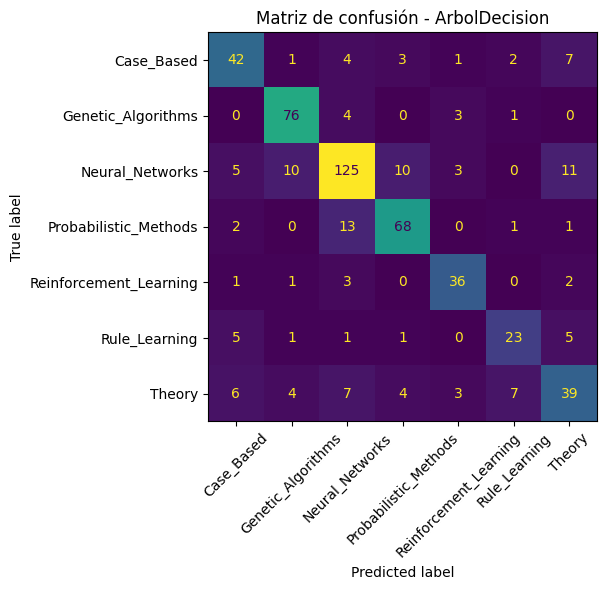

In [9]:
import matplotlib.pyplot as plt

mejor_nombre = resumen_test.iloc[0]["modelo"]
print(f"Mejor modelo en test (según F1 macro): {mejor_nombre}")

print("\nReporte por clase:\n")
print(reportes_clase[mejor_nombre])

labels_ordenados = np.unique(y_test)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=matrices_confusion[mejor_nombre],
    display_labels=labels_ordenados,
).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f"Matriz de confusión - {mejor_nombre}")
plt.tight_layout()
plt.show()

## 8. Persistencia de artefactos (trazabilidad)

Esta celda permite guardar los artefactos del experimento (métricas, reporte, modelo y metadatos) en una carpeta con timestamp.

- Por defecto esta desactivada (`GUARDAR_ARTEFACTOS = False`).
- Si la activas en `True`, se crea un directorio en `artifacts/tarea_2_1/<timestamp>/` con todo lo necesario para reproducir y auditar el resultado.

In [ ]:
# Persistencia opcional para trazabilidad de experimentos (activar bajo demanda).
from datetime import datetime
import json
from joblib import dump
import matplotlib.pyplot as plt

GUARDAR_ARTEFACTOS = False  # Cambia a True para activar la persistencia de artefactos

if GUARDAR_ARTEFACTOS:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    artifacts_dir = base_dir / "artifacts" / "tarea_2_1" / timestamp
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    figuras_dir = base_dir / "docs" / "trabajo" / "figuras"
    figuras_dir.mkdir(parents=True, exist_ok=True)

    # Tablas resumen
    resumen_cv.to_csv(artifacts_dir / "resumen_cv.csv", index=False)
    resumen_test.to_csv(artifacts_dir / "resumen_test.csv", index=False)

    # Reporte del mejor modelo
    with open(artifacts_dir / f"reporte_{mejor_nombre}.txt", "w", encoding="utf-8") as f:
        f.write(reportes_clase[mejor_nombre])

    # Serializacion del mejor modelo entrenado
    dump(mejores_modelos[mejor_nombre], artifacts_dir / f"modelo_{mejor_nombre}.joblib")

    # Copia de la matriz de confusion para el informe final
    labels_ordenados = np.unique(y_test)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(
        confusion_matrix=matrices_confusion[mejor_nombre],
        display_labels=labels_ordenados,
    ).plot(ax=ax_cm, xticks_rotation=45, colorbar=False)
    ax_cm.set_title(f"Matriz de confusion - {mejor_nombre}")
    fig_cm.tight_layout()

    ruta_figura = figuras_dir / f"matriz_confusion_{mejor_nombre}_{timestamp}.png"
    fig_cm.savefig(ruta_figura, dpi=300, bbox_inches="tight")
    plt.close(fig_cm)

    # Metadatos minimos para auditoria
    metadata = {
        "timestamp": timestamp,
        "dataset_fuente": fuente_datos,
        "random_state": RANDOM_STATE,
        "modelo_ganador": mejor_nombre,
        "ruta_figura_confusion": str(ruta_figura),
        "metricas_modelo_ganador": (
            resumen_test.loc[resumen_test["modelo"] == mejor_nombre]
            .iloc[0]
            .to_dict()
        ),
    }

    with open(artifacts_dir / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    print(f"Artefactos guardados en: {artifacts_dir}")
    print(f"Matriz de confusion guardada en: {ruta_figura}")
else:
    print("Persistencia desactivada. Cambia GUARDAR_ARTEFACTOS=True para guardar artefactos.")

Artefactos guardados en: /mnt/vms/aprendizaje-automatico-relacional/artifacts/tarea_2_1/20260527_124833
Matriz de confusion guardada en: /mnt/vms/aprendizaje-automatico-relacional/docs/trabajo/figuras/matriz_confusion_ArbolDecision_20260527_124833.png


## 9. Conclusiones y siguientes pasos

Con esta implementación tenemos un flujo completo y reproducible para modelos base en Cora:

1. Integración de información nativa y relacional.
2. Selección de hiperparámetros con validación cruzada estratificada.
3. Evaluación rigurosa en test con métricas globales y por clase.

Este resultado sirve como línea base sólida para comparar en tareas posteriores modelos más avanzados de aprendizaje sobre grafos.